#**Pengembangan Model Deep Learning: Klasifikasi Emosi Wajah (FaceMood AI)**

##1. Data Gathering (Pengumpulan Data)

a. Import dataset

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"jeliichan","key":"a889e07908c839efa028a487da4b6f48"}'}

b. Siapkan dan amankan file API Kaggle

In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

c. Unduh dan ekstrak dataset secara otomatis.

In [ ]:
!kaggle datasets download -d shuvoalok/raf-db-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/shuvoalok/raf-db-dataset
License(s): other
100% 37.7M/37.7M [00:00<00:00, 73.9MB/s]



e. Menampilkan struktur folder dataset.

In [ ]:
import os

for root, dirs, files in os.walk('.'):
    level = root.replace('.', '').count(os.sep)
    if level < 3:
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')

./
  .config/
    configurations/
    logs/
  DATASET/
    train/
    test/
  sample_data/


##2. Import Library

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import numpy as np
import os
from PIL import Image
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

##3. Data Assesing
Cek kualitas dataset

a. Menampilkan daftar kelas dan jumlah gambar pada dataset.

In [ ]:
train_path = './DATASET/train'
test_path = './DATASET/test'

kelas = os.listdir(train_path)
print("Kelas emosi yang tersedia:")
for k in sorted(kelas):
    jumlah = len(os.listdir(os.path.join(train_path, k)))
    print(f"  {k}: {jumlah} gambar")

print(f"\nTotal kelas: {len(kelas)}")

Kelas emosi yang tersedia:
  1: 1290 gambar
  2: 281 gambar
  3: 717 gambar
  4: 4772 gambar
  5: 1982 gambar
  6: 705 gambar
  7: 2524 gambar

Total kelas: 7


b. cek gambar yang rusak/tidak bisa dibaca

In [ ]:
corrupt_files = []

for label in os.listdir(train_path):
    label_path = os.path.join(train_path, label)

    if os.path.isdir(label_path):
        for file in os.listdir(label_path):
            file_path = os.path.join(label_path, file)

            try:
                img = Image.open(file_path)
                img.verify()

            except:
                corrupt_files.append(file_path)

print(f"Jumlah gambar rusak: {len(corrupt_files)}")

Jumlah gambar rusak: 0


c. Cek ukuran sample gambar

In [ ]:
for label in sorted(os.listdir(train_path)):
    label_path = os.path.join(train_path, label)

    if os.path.isdir(label_path):
        sample = os.listdir(label_path)[0]
        sample_path = os.path.join(label_path, sample)

        img = Image.open(sample_path)

        print(f"Kelas {label}: ukuran gambar {img.size}")

Kelas 1: ukuran gambar (100, 100)
Kelas 2: ukuran gambar (100, 100)
Kelas 3: ukuran gambar (100, 100)
Kelas 4: ukuran gambar (100, 100)
Kelas 5: ukuran gambar (100, 100)
Kelas 6: ukuran gambar (100, 100)
Kelas 7: ukuran gambar (100, 100)


d. Hasil data assesing

In [ ]:
train_path = './DATASET/train'

total_images = 0
corrupt_images = 0
image_sizes = set()

print("=== HASIL DATA ASSESSING DATASET ===\n")

for label in sorted(os.listdir(train_path)):
    label_path = os.path.join(train_path, label)

    if not os.path.isdir(label_path):
        continue

    image_count = 0

    for file in os.listdir(label_path):
        file_path = os.path.join(label_path, file)

        try:
            img = Image.open(file_path)
            image_sizes.add(img.size)
            img.verify()
            image_count += 1
            total_images += 1
        except:
            corrupt_images += 1
    print(f"Kelas {label}: {image_count} gambar valid")

print("\n=== RINGKASAN DATASET ===")
print(f"Total gambar valid : {total_images}")
print(f"Total gambar rusak : {corrupt_images}")
print(f"Jumlah variasi ukuran gambar : {len(image_sizes)}")
print(f"Contoh ukuran gambar : {list(image_sizes)[:5]}")

if corrupt_images == 0:
    print("\nSemua gambar valid dan dataset siap digunakan.")

=== HASIL DATA ASSESSING DATASET ===

Kelas 1: 1290 gambar valid
Kelas 2: 281 gambar valid
Kelas 3: 717 gambar valid
Kelas 4: 4772 gambar valid
Kelas 5: 1982 gambar valid
Kelas 6: 705 gambar valid
Kelas 7: 2524 gambar valid

=== RINGKASAN DATASET ===
Total gambar valid : 12271
Total gambar rusak : 0
Jumlah variasi ukuran gambar : 1
Contoh ukuran gambar : [(100, 100)]

Semua gambar valid dan dataset siap digunakan.


##4. EDA (Exploratory Data Analysis)

a. Contoh gambar dari setiap kelas emosi

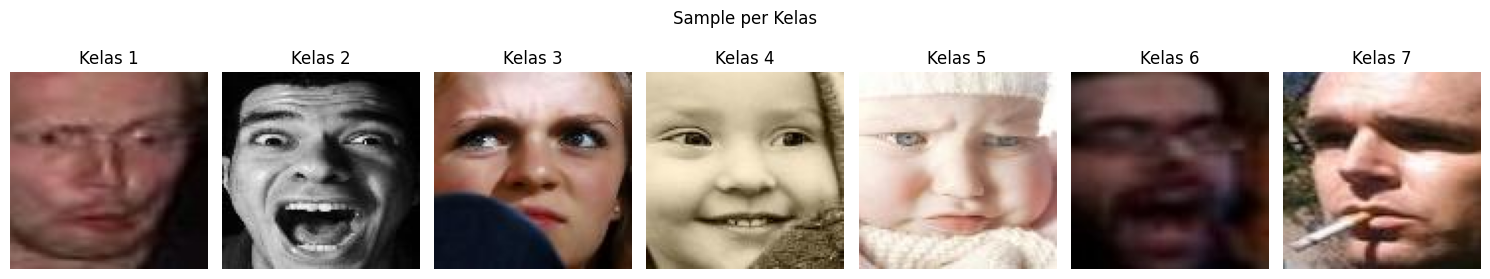

In [ ]:
fig, axes = plt.subplots(1, 7, figsize=(15, 3))

for i, kelas in enumerate(sorted(os.listdir(train_path))):
    folder = os.path.join(train_path, kelas)
    sample = os.listdir(folder)[0]
    img = mpimg.imread(os.path.join(folder, sample))
    axes[i].imshow(img)
    axes[i].set_title(f'Kelas {kelas}')
    axes[i].axis('off')

plt.suptitle('Sample per Kelas')
plt.tight_layout()
plt.show()

##5. Preprocessing Data

Menyiapkan data train dan test untuk model CNN

In [ ]:
emotion_labels = {
    '1': 'Surprise',
    '2': 'Fear',
    '3': 'Disgust',
    '4': 'Happy',
    '5': 'Sad',
    '6': 'Angry',
    '7': 'Neutral'
}
IMG_SIZE = 100
def load_data(folder_path):
    X, y = [], []
    printed_count = 0  # <--- Tambah ini untuk menghitung jumlah yang sudah di-print
    for label in sorted(os.listdir(folder_path)):
        label_path = os.path.join(folder_path, label)
        if not os.path.isdir(label_path):
            continue
        for img_file in os.listdir(label_path):
            img_path = os.path.join(label_path, img_file)
            try:
                img = Image.open(img_path).convert('RGB')
                img = img.resize((IMG_SIZE, IMG_SIZE))
                img_array = np.array(img) / 255.0
                X.append(img_array)
                y.append(int(label) - 1)
                if printed_count < 5:
                    print(f"File: {img_file} | Mode: {img.mode} | Ukuran: {img.size} | Rentang Piksel: {img_array.min()} s/d {img_array.max()}")
                    printed_count += 1

            except:
                continue
    return np.array(X), np.array(y)

print("Loading data training...")
X_train, y_train = load_data(train_path)
print("Loading data test...")
X_test, y_test = load_data(test_path)

y_train_cat = to_categorical(y_train, num_classes=7)
y_test_cat = to_categorical(y_test, num_classes=7)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

Loading data training...
File: train_02933_aligned.jpg | Mode: RGB | Ukuran: (100, 100) | Rentang Piksel: 0.0 s/d 0.8274509803921568
File: train_00126_aligned.jpg | Mode: RGB | Ukuran: (100, 100) | Rentang Piksel: 0.0 s/d 1.0
File: train_04003_aligned.jpg | Mode: RGB | Ukuran: (100, 100) | Rentang Piksel: 0.0 s/d 1.0
File: train_05663_aligned.jpg | Mode: RGB | Ukuran: (100, 100) | Rentang Piksel: 0.0 s/d 1.0
File: train_03371_aligned.jpg | Mode: RGB | Ukuran: (100, 100) | Rentang Piksel: 0.0 s/d 1.0
Loading data test...
File: test_0913_aligned.jpg | Mode: RGB | Ukuran: (100, 100) | Rentang Piksel: 0.0 s/d 1.0
File: test_1108_aligned.jpg | Mode: RGB | Ukuran: (100, 100) | Rentang Piksel: 0.0 s/d 1.0
File: test_0517_aligned.jpg | Mode: RGB | Ukuran: (100, 100) | Rentang Piksel: 0.0 s/d 1.0
File: test_0674_aligned.jpg | Mode: RGB | Ukuran: (100, 100) | Rentang Piksel: 0.0 s/d 1.0
File: test_1057_aligned.jpg | Mode: RGB | Ukuran: (100, 100) | Rentang Piksel: 0.0 s/d 1.0
X_train: (12271, 10

##6. Modelling Data

Membangun arsitektur model CNN

In [ ]:
model_raf = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(100,100,3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(7, activation='softmax')
])

model_raf.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_raf.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 50, 50, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,439,399 (20.75 MB)

 Trainable params: 5,436,903 (20.74 MB)

 Non-trainable params: 2,496 (9.75 KB)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.3589147286821706), 1: np.float64(6.238434163701068), 2: np.float64(2.4449093444909344), 3: np.float64(0.3673512154233026), 4: np.float64(0.884460141271443), 5: np.float64(2.4865248226950354), 6: np.float64(0.6945324881141046)}


##7. Training Model

Augmentasi data dan training model CNN

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ModelCheckpoint

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

datagen_raf = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen_raf.fit(X_train)

early_stop_raf = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr_raf = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
checkpoint = ModelCheckpoint(
    'facemood_raf_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history_raf = model_raf.fit(
    datagen_raf.flow(X_train, y_train_cat, batch_size=64),
    validation_data=(X_test, y_test_cat),
    epochs=50,
    callbacks=[early_stop_raf, reduce_lr_raf, checkpoint],
    class_weight=class_weight_dict
)

Class weights: {0: np.float64(1.3589147286821706), 1: np.float64(6.238434163701068), 2: np.float64(2.4449093444909344), 3: np.float64(0.3673512154233026), 4: np.float64(0.884460141271443), 5: np.float64(2.4865248226950354), 6: np.float64(0.6945324881141046)}
Epoch 1/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.1738 - loss: 2.6834
Epoch 1: val_accuracy improved from None to 0.05215, saving model to facemood_raf_model.h5



Epoch 1: finished saving model to facemood_raf_model.h5
192/192 ━━━━━━━━━━━━━━━━━━━━ 74s 285ms/step - accuracy: 0.1778 - loss: 2.5079 - val_accuracy: 0.0522 - val_loss: 3.8606 - learning_rate: 3.0000e-04
Epoch 2/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.1854 - loss: 2.2474
Epoch 2: val_accuracy improved from 0.05215 to 0.12256, saving model to facemood_raf_model.h5



Epoch 2: finished saving model to facemood_raf_model.h5
192/192 ━━━━━━━━━━━━━━━━━━━━ 39s 200ms/step - accuracy: 0.1993 - loss: 2.2186 - val_accuracy: 0.1226 - val_loss: 4.4796 - learning_rate: 3.0000e-04
Epoch 3/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.2188 - loss: 2.0606
Epoch 3: val_accuracy improved from 0.12256 to 0.14961, saving model to facemood_raf_model.h5



Epoch 3: finished saving model to facemood_raf_model.h5
192/192 ━━━━━━━━━━━━━━━━━━━━ 38s 199ms/step - accuracy: 0.2217 - loss: 2.0760 - val_accuracy: 0.1496 - val_loss: 4.8002 - learning_rate: 3.0000e-04
Epoch 4/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.2312 - loss: 2.0254
Epoch 4: val_accuracy improved from 0.14961 to 0.39113, saving model to facemood_raf_model.h5



Epoch 4: finished saving model to facemood_raf_model.h5
192/192 ━━━━━━━━━━━━━━━━━━━━ 39s 202ms/step - accuracy: 0.2366 - loss: 1.9998 - val_accuracy: 0.3911 - val_loss: 2.6756 - learning_rate: 3.0000e-04
Epoch 5/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.2614 - loss: 1.9656
Epoch 5: val_accuracy did not improve from 0.39113
192/192 ━━━━━━━━━━━━━━━━━━━━ 38s 195ms/step - accuracy: 0.2683 - loss: 1.9154 - val_accuracy: 0.3713 - val_loss: 3.4793 - learning_rate: 3.0000e-04
Epoch 6/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.2996 - loss: 1.8403
Epoch 6: val_accuracy improved from 0.39113 to 0.47718, saving model to facemood_raf_model.h5


...


Epoch 41: finished saving model to facemood_raf_model.h5
192/192 ━━━━━━━━━━━━━━━━━━━━ 37s 195ms/step - accuracy: 0.6915 - loss: 0.8734 - val_accuracy: 0.7516 - val_loss: 0.6953 - learning_rate: 7.5000e-05
Epoch 42/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.6996 - loss: 0.8361
Epoch 42: val_accuracy improved from 0.75163 to 0.75750, saving model to facemood_raf_model.h5



Epoch 42: finished saving model to facemood_raf_model.h5
192/192 ━━━━━━━━━━━━━━━━━━━━ 37s 192ms/step - accuracy: 0.6931 - loss: 0.8604 - val_accuracy: 0.7575 - val_loss: 0.6802 - learning_rate: 3.7500e-05
Epoch 43/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.6930 - loss: 0.8671
Epoch 43: val_accuracy improved from 0.75750 to 0.76532, saving model to facemood_raf_model.h5



Epoch 43: finished saving model to facemood_raf_model.h5
192/192 ━━━━━━━━━━━━━━━━━━━━ 37s 195ms/step - accuracy: 0.6901 - loss: 0.8644 - val_accuracy: 0.7653 - val_loss: 0.6518 - learning_rate: 3.7500e-05
Epoch 44/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.6998 - loss: 0.8301
Epoch 44: val_accuracy did not improve from 0.76532
192/192 ━━━━━━━━━━━━━━━━━━━━ 37s 193ms/step - accuracy: 0.6987 - loss: 0.8574 - val_accuracy: 0.7572 - val_loss: 0.6677 - learning_rate: 3.7500e-05
Epoch 45/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.6926 - loss: 0.8776
Epoch 45: val_accuracy did not improve from 0.76532
192/192 ━━━━━━━━━━━━━━━━━━━━ 37s 194ms/step - accuracy: 0.6937 - loss: 0.8653 - val_accuracy: 0.7591 - val_loss: 0.6711 - learning_rate: 3.7500e-05
Epoch 46/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.7028 - loss: 0.8408
Epoch 46: val_accuracy did not improve from 0.76532
192/192 ━━━━━━━━━━━━━━━━━━━━ 39s 201ms/step - accuracy: 0.6984 - loss: 0.84


Epoch 48: finished saving model to facemood_raf_model.h5
192/192 ━━━━━━━━━━━━━━━━━━━━ 38s 199ms/step - accuracy: 0.6949 - loss: 0.8455 - val_accuracy: 0.7669 - val_loss: 0.6550 - learning_rate: 1.8750e-05
Epoch 49/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.7035 - loss: 0.8200
Epoch 49: val_accuracy did not improve from 0.76695
192/192 ━━━━━━━━━━━━━━━━━━━━ 38s 200ms/step - accuracy: 0.7044 - loss: 0.8247 - val_accuracy: 0.7611 - val_loss: 0.6624 - learning_rate: 1.8750e-05
Epoch 50/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.7050 - loss: 0.8038
Epoch 50: val_accuracy improved from 0.76695 to 0.76760, saving model to facemood_raf_model.h5



Epoch 50: finished saving model to facemood_raf_model.h5
192/192 ━━━━━━━━━━━━━━━━━━━━ 38s 198ms/step - accuracy: 0.7053 - loss: 0.8137 - val_accuracy: 0.7676 - val_loss: 0.6499 - learning_rate: 9.3750e-06


##8. Evaluasi Model

a. Grafik akurasi dan loss model

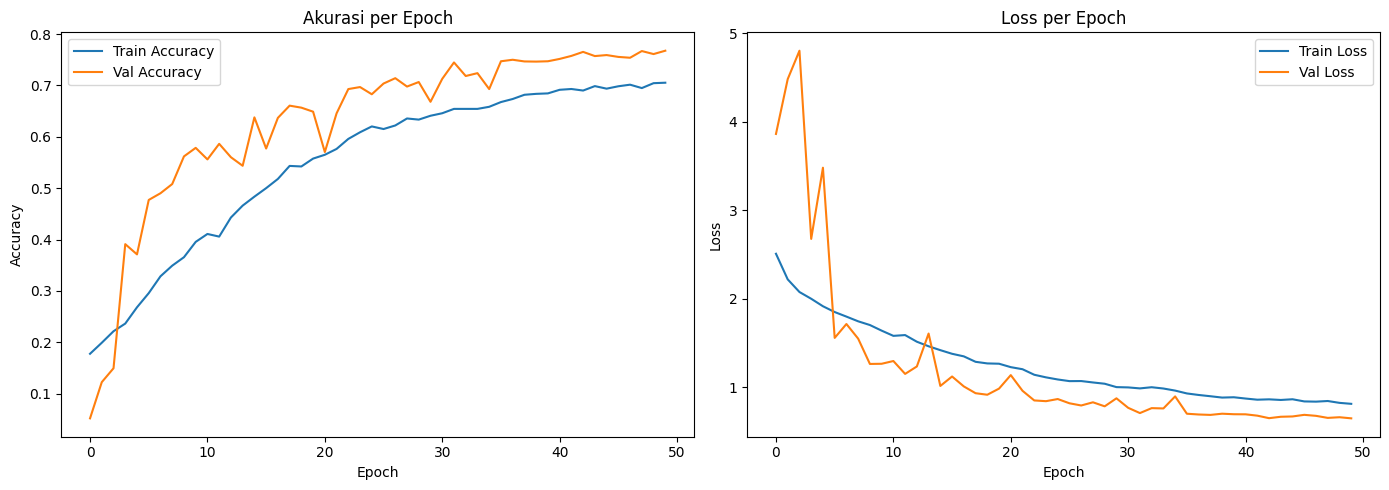

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_raf.history['accuracy'], label='Train Accuracy')
axes[0].plot(history_raf.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Akurasi per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_raf.history['loss'], label='Train Loss')
axes[1].plot(history_raf.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

b. Confusion matrix untuk melihat hasil prediksi model

96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step


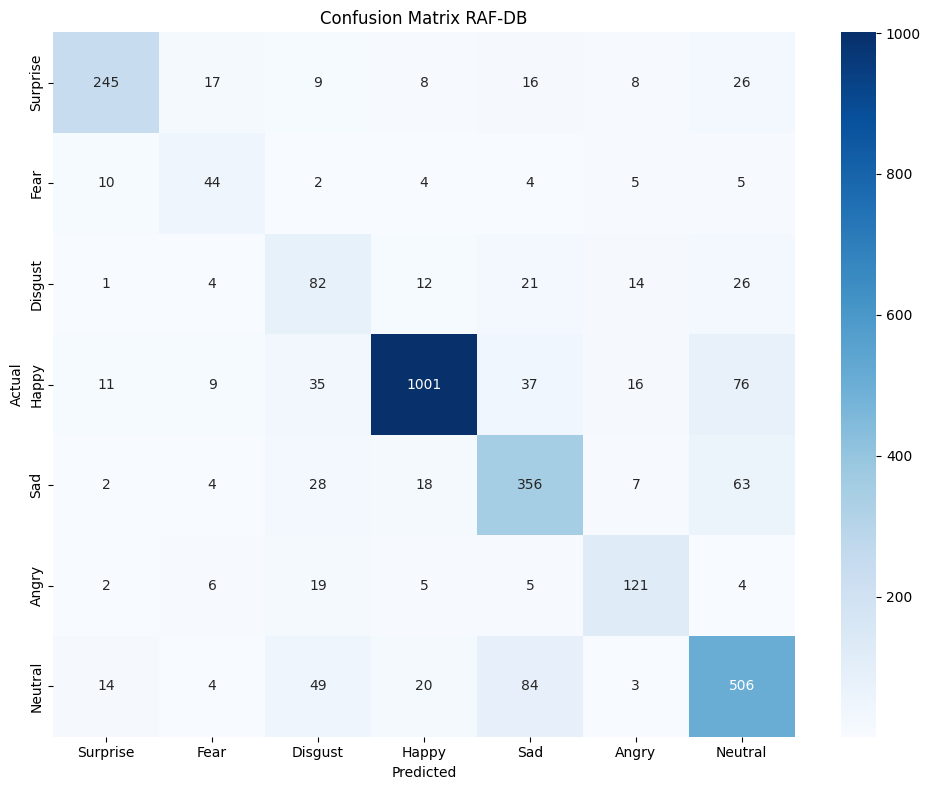

              precision    recall  f1-score   support

    Surprise       0.86      0.74      0.80       329
        Fear       0.50      0.59      0.54        74
     Disgust       0.37      0.51      0.43       160
       Happy       0.94      0.84      0.89      1185
         Sad       0.68      0.74      0.71       478
       Angry       0.70      0.75      0.72       162
     Neutral       0.72      0.74      0.73       680

    accuracy                           0.77      3068
   macro avg       0.68      0.70      0.69      3068
weighted avg       0.79      0.77      0.77      3068



In [ ]:
emotion_list = ['Surprise', 'Fear', 'Disgust', 'Happy', 'Sad', 'Angry', 'Neutral']

y_pred = model_raf.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_list,
            yticklabels=emotion_list)
plt.title('Confusion Matrix RAF-DB')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=emotion_list))

##9. Penyimpanan Model
Menyimpan dan mengunduh model CNN

In [ ]:
model_raf.save('facemood_raf_model.h5')
print("Model berhasil disimpan!")

from google.colab import files
files.download('facemood_raf_model.h5')

Model berhasil disimpan!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

(None, 7)
